# MoSeq Syllable Transition Probabilities — NSG vs. C57BL/6

This notebook computes and visualizes syllable-to-syllable transition probabilities from MoSeq data, comparing NSG and C57BL/6 (Bl6) mice at baseline (BSL) and 7 days post-stroke (CS_7DPI).

Transition probabilities capture the sequential structure of behavior — how likely an animal is to move from one behavioral syllable into another. Comparing these across groups reveals whether stroke or immune status alters the organization of behavioral sequences, beyond what raw syllable usage alone shows.

**Experimental groups:**
- `C57_BSL` — Bl6 mice at baseline
- `C57_CS_7DPI` — Bl6 mice, 7 days post-stroke
- `NSG_BSL` — NSG mice at baseline
- `NSG_CS_7DPI` — NSG mice, 7 days post-stroke

**Pipeline overview:**
1. Load MoSeq frame-level data and define a color palette for groups
2. Filter out initialization frames and inspect the syllable label space
3. Compute per-animal transition matrices from frame-level label sequences
4. Cluster syllables into four kinematic categories (motor/cognitive × deficit/improvement)
5. Compute the probability of transitioning into each cluster across animals
6. Compare transition probabilities across groups with statistical annotation

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
try:
    from statannotations.Annotator import Annotator
except:
    !pip install statannotations
    from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
import sys
is_venv = sys.prefix != sys.base_prefix
print(f"Inside virtual environment: {is_venv}")

Inside virtual environment: False


In [3]:
from google.colab.drive import mount

mount('/content/drive')

Mounted at /content/drive


In [10]:
#MODEL_PATH = Path('/mnt/g/Shared drives/llorente-lab/Moseq/RawData/Nature_Comm_Revisions/C57Bl6_MoSeq_Young_Males_CTRL_CS_BSL_7DPI/applied_models/final-model-000-12742750')
MODEL_PATH = Path('/content/drive/My Drive/Moseq/RawData/Nature_Comm_Revisions/C57Bl6_MoSeq_Young_Males_CTRL_CS_BSL_7DPI/applied_models/final_model_pretrained')
MOSEQ_DF_PATH = MODEL_PATH / 'moseq_df.csv'
STATS_DF_PATH = MODEL_PATH / 'stats_df.csv'

moseq_df = pd.read_csv(MOSEQ_DF_PATH)
stats_df = pd.read_csv(STATS_DF_PATH)

print(moseq_df.shape)
print(stats_df.shape)

/tmp/ipykernel_20832/2319315728.py:6: DtypeWarning: Columns (30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  moseq_df = pd.read_csv(MOSEQ_DF_PATH)


(2423892, 33)
(2680, 90)


# 1. Data Loading

Load the MoSeq frame-level dataframe (`moseq_df`) from a pre-trained model applied to all four experimental groups. Each row is one frame annotated with its syllable label and kinematic features. `stats_df` contains per-session summary statistics.

In [45]:
save_path = '/content/drive/My Drive/Moseq/RawData/Nature_Comm_Revisions/C57Bl6_MoSeq_Young_Males_CTRL_CS_BSL_7DPI/figures-oldmodel/'
SAVE_PATH = Path(save_path)
SAVE_PATH.exists()

True

In [5]:
palette = {
    'C57_BSL': '#FFCC80',      # light orange
    'C57_CS_7DPI': '#7B2D00',  # deep orange/brown
    'NSG_BSL': '#00838F',      # teal
    'NSG_CS_7DPI': '#004D56',  # deep teal
}

In [11]:
moseq_df = moseq_df[moseq_df['labels (usage sort)'] >= 0]
moseq_df.shape # make sure it's all okay

(2423691, 33)

# 2. Preprocessing

Remove initialization frames (label = -5) emitted by the model at the start of each session. These do not represent real behavioral syllables.

In [12]:
def compute_transition_matrix(label_sequence, n_syllables=None):
    labels = np.array(label_sequence)

    if n_syllables is None:
        n_syllables = int(labels.max()) + 1

    T_counts = np.zeros((n_syllables, n_syllables), dtype=np.float64)

    # Consecutive pairs: (labels[t], labels[t+1])
    from_labels = labels[:-1]
    to_labels   = labels[1:]

    # Vectorized count accumulation
    np.add.at(T_counts, (from_labels, to_labels), 1)

    # Row-normalize (rows with zero transitions -> zero row, avoids NaN)
    row_sums = T_counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid division by zero
    T = T_counts / row_sums

    return T

# 3. Transition Matrix Computation

For each animal, build a row-normalized transition matrix **T** of shape `(n_syllables × n_syllables)`, where `T[i, j]` is the empirical probability of transitioning from syllable *i* to syllable *j* on the next frame. Frames are ordered by session and frame index to preserve temporal structure within each recording.

In [13]:
np.size(moseq_df['labels (usage sort)'].sort_values().unique())

40

In [ ]:
n_syllables = 54

# Filter moseq_df to only include syllables 0–53
moseq_df_filtered = moseq_df[
    (moseq_df['labels (usage sort)'] >= 0) &
    (moseq_df['labels (usage sort)'] <= 53)
]

print(f"Number of syllables: {n_syllables} (labels 0–53 inclusive)")

Number of syllables: 54 (labels 0–53 inclusive)


In [ ]:
moseq_df['labels (usage sort)'].sort_values().unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39])

In [14]:
moseq_df.columns

Index(['labels (original)', 'labels (usage sort)', 'labels (frames sort)',
       'onset', 'frame index', 'syllable index', 'kappa', 'model_type',
       'angle', 'area_mm', 'area_px', 'centroid_x_mm', 'centroid_x_px',
       'centroid_y_mm', 'centroid_y_px', 'height_ave_mm', 'length_mm',
       'length_px', 'velocity_2d_mm', 'velocity_2d_px', 'velocity_3d_mm',
       'velocity_3d_px', 'velocity_theta', 'width_mm', 'width_px',
       'dist_to_center_px', 'group', 'uuid', 'h5_path', 'timestamps',
       'SessionName', 'StartTime', 'SubjectName'],
      dtype='object')

In [15]:
moseq_df['group'].unique()

array(['C57_CS_7DPI', 'C57_BSL', 'NSG_BSL', 'NSG_CS_7DPI'], dtype=object)

In [16]:
mouse_transition_matrices = {}   # uuid -> T (n_syllables x n_syllables)
mouse_metadata = {}              # uuid -> {group}

meta_cols = ['group']
n_syllables = max(moseq_df['labels (usage sort)'].unique()) + 1

for uuid, mouse_df in moseq_df.groupby('uuid'):
    # Sort by session then frame index to preserve temporal order
    mouse_df = mouse_df.sort_values(['SessionName', 'frame index'])

    labels = mouse_df['labels (usage sort)'].values.astype(int)

    T = compute_transition_matrix(labels, n_syllables=n_syllables)
    mouse_transition_matrices[uuid] = T

    # Store metadata (take first row — same for all rows of a given mouse)
    mouse_metadata[uuid] = {
        col: mouse_df[col].iloc[0] for col in meta_cols if col in mouse_df.columns
    }

print(f"Computed transition matrices for {len(mouse_transition_matrices)} mice.")
print(f"Matrix shape per mouse: {next(iter(mouse_transition_matrices.values())).shape}")

Computed transition matrices for 67 mice.
Matrix shape per mouse: (40, 40)


In [17]:
group_matrices = defaultdict(list)

for uuid, T in mouse_transition_matrices.items():
    grp = mouse_metadata[uuid].get('group', 'unknown')
    group_matrices[grp].append(T)

group_avg_matrices = {
    grp: np.mean(np.stack(matrices, axis=0), axis=0)
    for grp, matrices in group_matrices.items()
}

for grp, T_avg in group_avg_matrices.items():
    n = len(group_matrices[grp])
    print(f"  Group '{grp}': averaged over {n} mice | T shape: {T_avg.shape}")

  Group 'NSG_CS_7DPI': averaged over 10 mice | T shape: (40, 40)
  Group 'NSG_BSL': averaged over 36 mice | T shape: (40, 40)
  Group 'C57_CS_7DPI': averaged over 10 mice | T shape: (40, 40)
  Group 'C57_BSL': averaged over 11 mice | T shape: (40, 40)


In [18]:
records = []
for uuid, T in mouse_transition_matrices.items():
    row = {'uuid': uuid}
    row.update(mouse_metadata[uuid])
    # T flattened: feature named "T_i_j"
    for i in range(n_syllables):
        for j in range(n_syllables):
            row[f'T_{i}_{j}'] = T[i, j]
    records.append(row)

transition_feature_df = pd.DataFrame(records)
print(f"\ntransition_feature_df shape: {transition_feature_df.shape}")
print(transition_feature_df.iloc[:, :10].head())


transition_feature_df shape: (67, 1602)
                                   uuid        group     T_0_0     T_0_1  \
0  0495026a-4db6-47fe-8144-06fe2721835c  NSG_CS_7DPI  0.910217  0.000000   
1  1238c0d7-b5b3-484d-91d5-abd52b008cfa      NSG_BSL  0.898305  0.000000   
2  1e3d9fa2-899b-411d-a6c8-e210b8036de5      NSG_BSL  0.887734  0.000000   
3  1e5ceab1-2849-408c-881b-faee0fd9f18d      NSG_BSL  0.916190  0.000000   
4  2663dbe4-69ba-4999-8af4-8c10e1c5de44  C57_CS_7DPI  0.943047  0.000121   

      T_0_2     T_0_3     T_0_4     T_0_5     T_0_6  T_0_7  
0  0.007740  0.003096  0.000000  0.003096  0.000000    0.0  
1  0.011299  0.000000  0.000000  0.000000  0.000000    0.0  
2  0.008316  0.006237  0.000000  0.006237  0.000000    0.0  
3  0.019048  0.001905  0.000000  0.001905  0.000000    0.0  
4  0.012213  0.003386  0.000605  0.001088  0.000484    0.0  


In [19]:
syllable_kinematics = (
    moseq_df
    .groupby('labels (usage sort)')
    .agg(
        mean_velocity=('velocity_3d_mm', 'mean'),
        mean_displacement=('dist_to_center_px', 'mean'),
        n=('velocity_3d_mm', 'count')
    )
    .reset_index()
    .rename(columns={'labels (usage sort)': 'syllable'})
)
syllable_kinematics = syllable_kinematics[syllable_kinematics['n'] >= 5].reset_index(drop=True)

# 4. Syllable Kinematic Clustering

Assign each syllable to one of four behavioral clusters based on median splits of mean velocity and distance-to-center (displacement proxy). The manual `syl_to_cluster` dictionary below overrides the data-driven split to reflect validated cluster assignments used consistently across notebooks.

In [27]:
syllable_kinematics = syllable_kinematics.sort_values('mean_displacement').reset_index(drop=True)
mid = len(syllable_kinematics) // 2
syllable_kinematics['disp_group'] = 'high_disp'
syllable_kinematics.loc[:mid-1, 'disp_group'] = 'low_disp'

clusters = []
for name, grp in syllable_kinematics.groupby('disp_group'):
    grp = grp.sort_values('mean_velocity').reset_index(drop=True)
    mid = len(grp) // 2
    grp['vel_group'] = 'high_vel'
    grp.loc[:mid-1, 'vel_group'] = 'low_vel'
    grp['cluster'] = grp['disp_group'] + '_' + grp['vel_group']
    clusters.append(grp)

syllable_kinematics = pd.concat(clusters).reset_index(drop=True)
syl_to_cluster = syllable_kinematics.set_index('syllable')['cluster'].to_dict()

In [21]:
syl_to_cluster = {
    # high_disp_high_vel - Motor Related Improvement
    1: "high_disp_high_vel",
    4: "high_disp_high_vel",
    13: "high_disp_high_vel",
    14: "high_disp_high_vel",
    15: "high_disp_high_vel",
    18: "high_disp_high_vel",
    21: "high_disp_high_vel",
    23: "high_disp_high_vel",
    38: "high_disp_high_vel",
    39: "high_disp_high_vel",

    # high_disp_low_vel - Motor Related Deficit
    3: "high_disp_low_vel",
    7: "high_disp_low_vel",
    8: "high_disp_low_vel",
    10: "high_disp_low_vel",
    16: "high_disp_low_vel",
    17: "high_disp_low_vel",
    24: "high_disp_low_vel",
    25: "high_disp_low_vel",
    26: "high_disp_low_vel",
    33: "high_disp_low_vel",

    # low_disp_low_vel - Cognitive Related Deficit
    0: "low_disp_low_vel",
    11: "low_disp_low_vel",
    22: "low_disp_low_vel",
    27: "low_disp_low_vel",
    28: "low_disp_low_vel",
    29: "low_disp_low_vel",
    31: "low_disp_low_vel",
    32: "low_disp_low_vel",
    35: "low_disp_low_vel",
    37: "low_disp_low_vel",

    # low_disp_high_vel - Cognitive Related Improvement
    2: "low_disp_high_vel",
    5: "low_disp_high_vel",
    6: "low_disp_high_vel",
    9: "low_disp_high_vel",
    12: "low_disp_high_vel",
    19: "low_disp_high_vel",
    20: "low_disp_high_vel",
    30: "low_disp_high_vel",
    34: "low_disp_high_vel",
    36: "low_disp_high_vel",
}

In [28]:
moseq_df['cluster'] = moseq_df['labels (usage sort)'].map(syl_to_cluster)

In [24]:
id_to_cluster = df_syllable_kinematics.set_index('syllable')['cluster'].to_dict()
id_to_cluster

{0: 'low_disp_low_vel',
 1: 'high_disp_high_vel',
 2: 'low_disp_high_vel',
 3: 'high_disp_low_vel',
 4: 'high_disp_high_vel',
 5: 'low_disp_high_vel',
 6: 'high_disp_low_vel',
 7: 'low_disp_high_vel',
 8: 'high_disp_low_vel',
 9: 'low_disp_high_vel',
 10: 'high_disp_low_vel',
 11: 'high_disp_high_vel',
 12: 'high_disp_high_vel',
 13: 'high_disp_high_vel',
 14: 'low_disp_low_vel',
 15: 'low_disp_high_vel',
 16: 'high_disp_high_vel',
 17: 'low_disp_high_vel',
 18: 'low_disp_high_vel',
 19: 'high_disp_low_vel',
 20: 'high_disp_high_vel',
 21: 'high_disp_low_vel',
 22: 'high_disp_high_vel',
 23: 'low_disp_low_vel',
 24: 'high_disp_low_vel',
 25: 'low_disp_low_vel',
 26: 'low_disp_low_vel',
 27: 'low_disp_high_vel',
 28: 'low_disp_low_vel',
 29: 'high_disp_low_vel',
 30: 'low_disp_low_vel',
 31: 'high_disp_low_vel',
 32: 'low_disp_low_vel',
 33: 'high_disp_low_vel',
 34: 'low_disp_high_vel',
 35: 'low_disp_low_vel',
 36: 'low_disp_low_vel',
 37: 'low_disp_high_vel',
 38: 'high_disp_high_vel

In [29]:
cluster_to_ids = defaultdict(list)
for syl_id, cluster_name in id_to_cluster.items():
    cluster_to_ids[cluster_name].append(syl_id)

cluster_names = ['high_disp_high_vel', 'low_disp_high_vel',
                 'high_disp_low_vel',  'low_disp_low_vel']

# Syllable-level cluster index (0–3) for matrix reordering/coloring
cluster_name_to_idx = {name: i for i, name in enumerate(cluster_names)}
syl_to_cluster_idx  = np.array([cluster_name_to_idx[id_to_cluster[i]] for i in range(40)])

print("Syllable → cluster index:", syl_to_cluster_idx)

Syllable → cluster index: [3 0 1 2 0 1 2 1 2 1 2 0 0 0 3 1 0 1 1 2 0 2 0 3 2 3 3 1 3 2 3 2 3 2 1 3 3
 1 0 0]


In [30]:
print(moseq_df['group'].unique())

['C57_CS_7DPI' 'C57_BSL' 'NSG_BSL' 'NSG_CS_7DPI']


In [31]:
meta_cols = ['uuid', 'group']

mouse_meta_df = (moseq_df[meta_cols]
                 .drop_duplicates(subset='uuid')
                 .set_index('uuid'))

In [32]:
mouse_meta_df

,group
uuid,
e80a14ef-db7c-49d0-88d9-e82a7b6a6f87,C57_CS_7DPI
7b54cd86-02a8-426b-9199-643557d595b6,C57_CS_7DPI
9d287d05-3670-4fdf-aa8e-721f66176e35,C57_CS_7DPI
b01028f3-2463-41c9-9251-01dd951a570c,C57_CS_7DPI
75c0cde2-1526-4e46-b22c-9071d816b8c9,C57_CS_7DPI
...,...
3bcd6a41-7b1a-4999-b9cb-c0115c3969aa,NSG_CS_7DPI
593de73e-55df-4fe3-87f5-c1539cf05a8e,NSG_CS_7DPI
a3ca4180-e131-4573-88e0-bf31583ff251,NSG_CS_7DPI


# 5. Statistical Comparisons

All comparisons use Mann-Whitney U tests with Bonferroni correction for multiple comparisons. Outliers are removed per group using the 1.5×IQR rule before plotting. Statistical annotations follow: `*` p < 0.05, `**` p < 0.01, `***` p < 0.001, `ns` not significant.

## 5.1 Overall Transition Probability

Compute the mean transition probability across all syllable pairs per animal (i.e., the mean of all entries in the transition matrix). This gives a single scalar summarizing how often animals switch behavioral states, regardless of which states are involved.

In [33]:
transition_feature_df['mean'] = transition_feature_df.iloc[:,2:transition_feature_df.shape[1]].mean(axis=1)
transition_feature_df['median'] = transition_feature_df.iloc[:,2:transition_feature_df.shape[1]].median(axis=1)

In [34]:
transition_feature_df

,uuid,group,T_0_0,T_0_1,T_0_2,T_0_3,T_0_4,T_0_5,T_0_6,T_0_7,...,T_39_32,T_39_33,T_39_34,T_39_35,T_39_36,T_39_37,T_39_38,T_39_39,mean,median
0,0495026a-4db6-47fe-8144-06fe2721835c,NSG_CS_7DPI,0.910217,0.000000,0.007740,0.003096,0.000000,0.003096,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023750,0.0
1,1238c0d7-b5b3-484d-91d5-abd52b008cfa,NSG_BSL,0.898305,0.000000,0.011299,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023750,0.0
2,1e3d9fa2-899b-411d-a6c8-e210b8036de5,NSG_BSL,0.887734,0.000000,0.008316,0.006237,0.000000,0.006237,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023750,0.0
3,1e5ceab1-2849-408c-881b-faee0fd9f18d,NSG_BSL,0.916190,0.000000,0.019048,0.001905,0.000000,0.001905,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024375,0.0
4,2663dbe4-69ba-4999-8af4-8c10e1c5de44,C57_CS_7DPI,0.943047,0.000121,0.012213,0.003386,0.000605,0.001088,0.000484,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.018750,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,f2b556a5-762c-4cc7-8ee0-01f554b4355f,C57_BSL,0.940873,0.000313,0.019709,0.001408,0.001408,0.001564,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018750,0.0
63,f367427c-58b6-4e8a-8bcb-58992b4b685e,NSG_BSL,0.915285,0.000000,0.011050,0.003683,0.000000,0.001842,0.000000,0.001842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023750,0.0
64,f7c2f6c2-97b7-4e09-87c3-e2db49b049d7,NSG_BSL,0.876923,0.000000,0.015385,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023750,0.0
65,fbc7f5c7-675f-4497-b424-745bae81e566,NSG_BSL,0.940364,0.000000,0.005818,0.003636,0.000000,0.003636,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023750,0.0


In [35]:
plot_df = transition_feature_df[['uuid','group','mean']]

In [37]:
plot_df.head()

,uuid,group,mean
0,0495026a-4db6-47fe-8144-06fe2721835c,NSG_CS_7DPI,0.023750
1,1238c0d7-b5b3-484d-91d5-abd52b008cfa,NSG_BSL,0.023750
2,1e3d9fa2-899b-411d-a6c8-e210b8036de5,NSG_BSL,0.023750
3,1e5ceab1-2849-408c-881b-faee0fd9f18d,NSG_BSL,0.024375
4,2663dbe4-69ba-4999-8af4-8c10e1c5de44,C57_CS_7DPI,0.018750


In [38]:
def remove_outliers_iqr(df, value_col, group_cols):
    """Remove outliers using 1.5×IQR rule within each group."""
    mask = pd.Series(True, index=df.index)
    for keys, grp in df.groupby(group_cols):
        Q1  = grp[value_col].quantile(0.25)
        Q3  = grp[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outlier_idx = grp[(grp[value_col] < lo) | (grp[value_col] > hi)].index
        mask[outlier_idx] = False
    return df[mask]

In [39]:
z = len(plot_df)
print(f"Before: {z} rows")
plot_df_clean = remove_outliers_iqr(plot_df[['uuid','mean','group']], 'mean', ['group'])
print(f"After:  {len(plot_df_clean)} rows")
print(f"Removed: {len(plot_df_clean) - z} outliers")

Before: 67 rows
After:  52 rows
Removed: -15 outliers


In [41]:
order = ['C57_BSL','C57_CS_7DPI', 'NSG_BSL', 'NSG_CS_7DPI']

/tmp/ipykernel_20832/2438315550.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.640e-01 U_stat=8.450e+01
NSG_BSL vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:9.628e-01 U_stat=2.245e+02
C57_BSL vs. NSG_BSL: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.714e-06 U_stat=0.000e+00
C57_CS_7DPI vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.032e-03 U_stat=6.000e+00


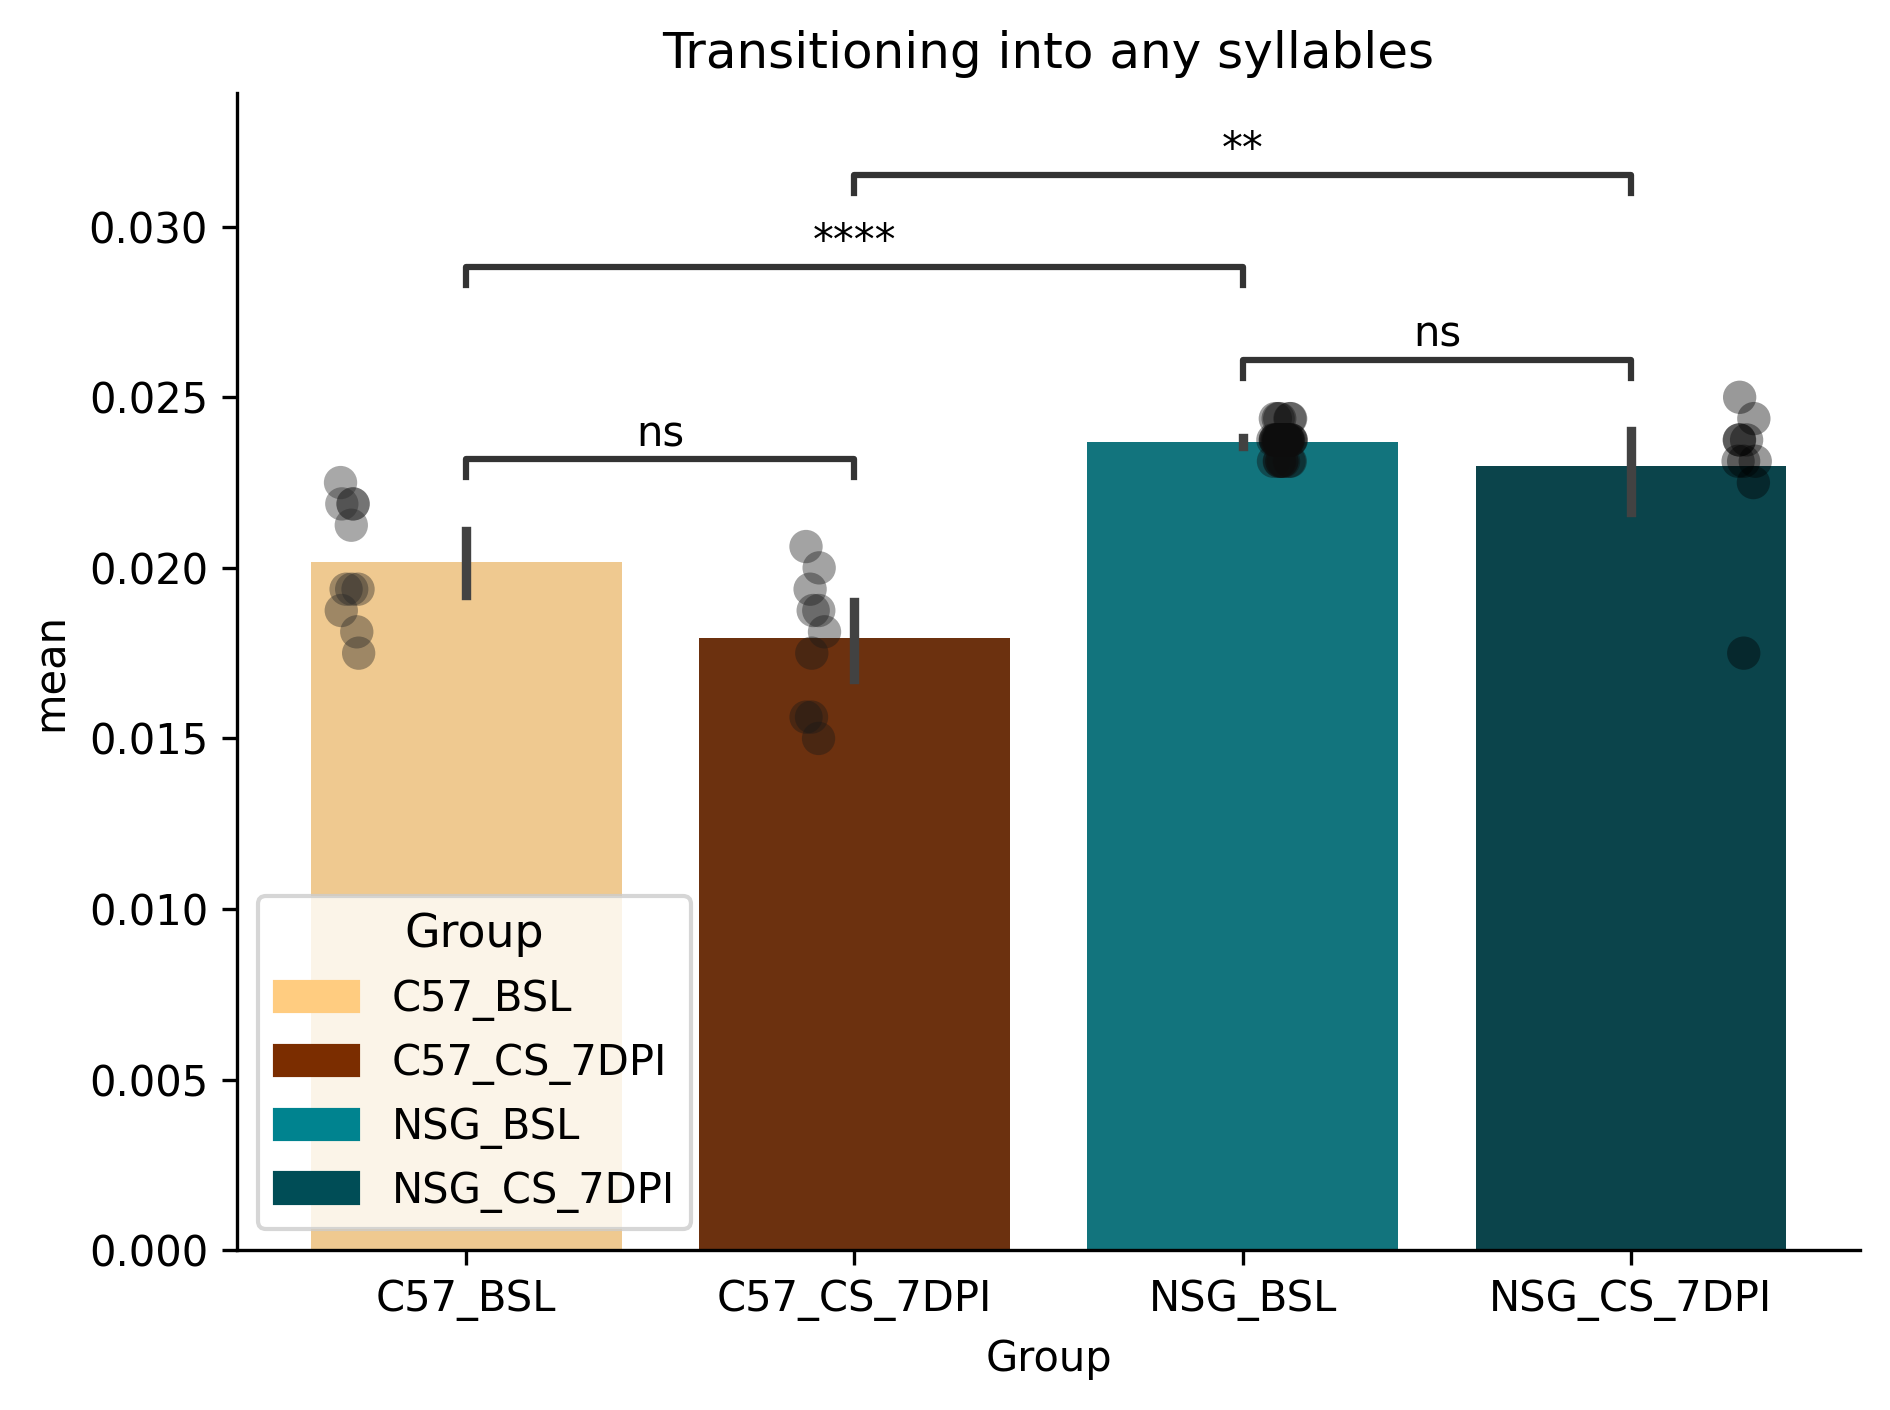

In [46]:
from matplotlib.patches import Patch


fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df,
    x='group', y='mean', hue='group',
    palette=palette,
    order=order,
    hue_order=order,
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x='group', y='mean', hue='group',
    order=order,
    hue_order=order,
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

pairs = [
    ("C57_BSL", "C57_CS_7DPI"),
    ("NSG_BSL", "NSG_CS_7DPI"),
    ("C57_BSL", "NSG_BSL"),
    ("C57_CS_7DPI", "NSG_CS_7DPI"),
]

annotator = Annotator(
    ax, pairs=pairs,
    data=plot_df, x="group", y="mean", order=order
)
annotator.configure(test="Mann-Whitney", comparisons_correction='Bonferroni', text_format="star", loc="inside", verbose=2)
annotator.apply_and_annotate()

ax.set_xlabel('Group')

present_groups = plot_df_clean['group'].unique()
handles = [Patch(color=palette[g], label=g) for g in order if g in present_groups]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.title('Transitioning into any syllables')
plt.tight_layout()
plt.savefig(SAVE_PATH / 'Transition_Probability_To_Any_Syllables.pdf')
plt.show()

## 5.2 Cluster-Specific Transition Probabilities

For each behavioral cluster, compute the probability that an animal transitions *into* that cluster from any syllable outside it. This is the mean row-sum of the sub-matrix `T[non_cluster_syllables, cluster_syllables]`, averaged across all non-cluster source states. This metric captures how likely an animal's behavior is to be "attracted" toward each cluster.

In [47]:
# P(transitioning into motor deficit)
lvhd_syllables = [s for s, c in id_to_cluster.items() if c == 'high_disp_low_vel']
non_lvhd_syllables = [s for s, c in id_to_cluster.items() if c != 'high_disp_low_vel']

# P(transitioning into cognitive deficit)
lvld_syllables = [s for s, c in id_to_cluster.items() if c == 'low_disp_low_vel']
non_lvld_syllables = [s for s, c in id_to_cluster.items() if c != 'low_disp_low_vel']

# P(transitioning into motor improvement)
hvhd_syllables = [s for s, c in id_to_cluster.items() if c == 'high_disp_high_vel']
non_hvhd_syllables = [s for s, c in id_to_cluster.items() if c != 'high_disp_high_vel']

# P(transitioning into cognitive improvement)
hvld_syllables = [s for s, c in id_to_cluster.items() if c == 'low_disp_high_vel']
non_hvld_syllables = [s for s, c in id_to_cluster.items() if c != 'low_disp_high_vel']

In [48]:
records = []

for uuid, T in mouse_transition_matrices.items():
    if uuid not in mouse_meta_df.index:
        continue
    meta = mouse_meta_df.loc[uuid]

    sub_matrix = T[np.ix_(non_lvhd_syllables, lvhd_syllables)]
    p_scalar_lvhd   = sub_matrix.sum(axis=1).mean()

    sub_matrix = T[np.ix_(non_lvld_syllables, lvld_syllables)]
    p_scalar_lvld   = sub_matrix.sum(axis=1).mean()

    sub_matrix = T[np.ix_(non_hvhd_syllables, hvhd_syllables)]
    p_scalar_hvhd   = sub_matrix.sum(axis=1).mean()

    sub_matrix = T[np.ix_(non_hvld_syllables, hvld_syllables)]
    p_scalar_hvld   = sub_matrix.sum(axis=1).mean()

    records.append({
        'uuid':      uuid,
        'p_lvhd':    p_scalar_lvhd,
        'p_lvld':    p_scalar_lvld,
        'p_hvhd':    p_scalar_hvhd,
        'p_hvld':    p_scalar_hvld,
        'group':     meta['group'],
    })

plot_df = pd.DataFrame(records)
print(plot_df.shape)
print(plot_df['group'].value_counts())

(67, 6)
group
NSG_BSL        36
C57_BSL        11
NSG_CS_7DPI    10
C57_CS_7DPI    10
Name: count, dtype: int64


In [49]:
plot_df.head()

,uuid,p_lvhd,p_lvld,p_hvhd,p_hvld,group
0,0495026a-4db6-47fe-8144-06fe2721835c,0.016152,0.019324,0.028223,0.014539,NSG_CS_7DPI
1,1238c0d7-b5b3-484d-91d5-abd52b008cfa,0.012610,0.011428,0.032321,0.023098,NSG_BSL
2,1e3d9fa2-899b-411d-a6c8-e210b8036de5,0.018812,0.009590,0.027812,0.022426,NSG_BSL
3,1e5ceab1-2849-408c-881b-faee0fd9f18d,0.029191,0.005902,0.034449,0.025991,NSG_BSL
4,2663dbe4-69ba-4999-8af4-8c10e1c5de44,0.042096,0.031859,0.007396,0.055821,C57_CS_7DPI


In [50]:
plot_df['group'] = pd.Categorical(plot_df['group'],categories=order, ordered=True)
plot_df = plot_df.sort_values('group')
plot_df.sample(5)

,uuid,p_lvhd,p_lvld,p_hvhd,p_hvld,group
40,89b6a658-c876-4f02-ae2c-4de98b00a0db,0.032468,0.013522,0.032553,0.027568,C57_BSL
59,e3f3f8ce-b89b-47f0-89f6-4cac329e9a12,0.012464,0.020736,0.030852,0.027982,C57_CS_7DPI
5,2d459cfd-aaa0-4bb6-8ecd-31c6592bff23,0.007811,0.013048,0.012401,0.002678,NSG_CS_7DPI
3,1e5ceab1-2849-408c-881b-faee0fd9f18d,0.029191,0.005902,0.034449,0.025991,NSG_BSL
39,8857e5f4-042a-48ba-8da8-6dd01a568e48,0.014941,0.012224,0.031134,0.033568,NSG_BSL


In [51]:
z = len(plot_df)
print(f"Before: {z} rows")
plot_df_clean_lvhd = remove_outliers_iqr(plot_df[['uuid','p_lvhd','group']], 'p_lvhd', ['group'])
print(f"After:  {len(plot_df_clean_lvhd)} rows")
print(f"Removed: {len(plot_df_clean_lvhd) - z} outliers")

Before: 67 rows
After:  60 rows
Removed: -7 outliers


/tmp/ipykernel_20832/3034503872.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, grp in df.groupby(group_cols):


In [52]:
z = len(plot_df)
print(f"Before: {z} rows")
plot_df_clean_lvld = remove_outliers_iqr(plot_df[['uuid','p_lvld','group']], 'p_lvld', ['group'])
print(f"After:  {len(plot_df_clean_lvld)} rows")
print(f"Removed: {len(plot_df_clean_lvld) - z} outliers")

Before: 67 rows
After:  64 rows
Removed: -3 outliers


/tmp/ipykernel_20832/3034503872.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, grp in df.groupby(group_cols):


In [53]:
z = len(plot_df)
print(f"Before: {z} rows")
plot_df_clean_hvld = remove_outliers_iqr(plot_df[['uuid','p_hvld','group']], 'p_hvld', ['group'])
print(f"After:  {len(plot_df_clean_hvld)} rows")
print(f"Removed: {len(plot_df_clean_hvld) - z} outliers")

Before: 67 rows
After:  64 rows
Removed: -3 outliers


/tmp/ipykernel_20832/3034503872.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, grp in df.groupby(group_cols):


In [54]:
z = len(plot_df)
print(f"Before: {z} rows")
plot_df_clean_hvhd = remove_outliers_iqr(plot_df[['uuid','p_hvhd','group']], 'p_hvhd', ['group'])
print(f"After:  {len(plot_df_clean_hvhd)} rows")
print(f"Removed: {len(plot_df_clean_hvhd) - z} outliers")

Before: 67 rows
After:  64 rows
Removed: -3 outliers


/tmp/ipykernel_20832/3034503872.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, grp in df.groupby(group_cols):


### 5.2.1 Transition into Motor Deficit Syllables (`high_disp_low_vel`)

High displacement, low velocity syllables — interpreted as effortful or stereotyped movements associated with motor impairment. An increase in transition probability into this cluster post-stroke suggests reduced motor fluency.

/tmp/ipykernel_20832/1492318164.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:4.379e-01 U_stat=3.500e+01
NSG_BSL vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:4.220e-02 U_stat=7.900e+01
C57_BSL vs. NSG_BSL: Mann-Whitney-Wilcoxon test two-sided, P_val:2.253e-01 U_stat=1.050e+02
C57_CS_7DPI vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:7.751e-01 U_stat=4.900e+01


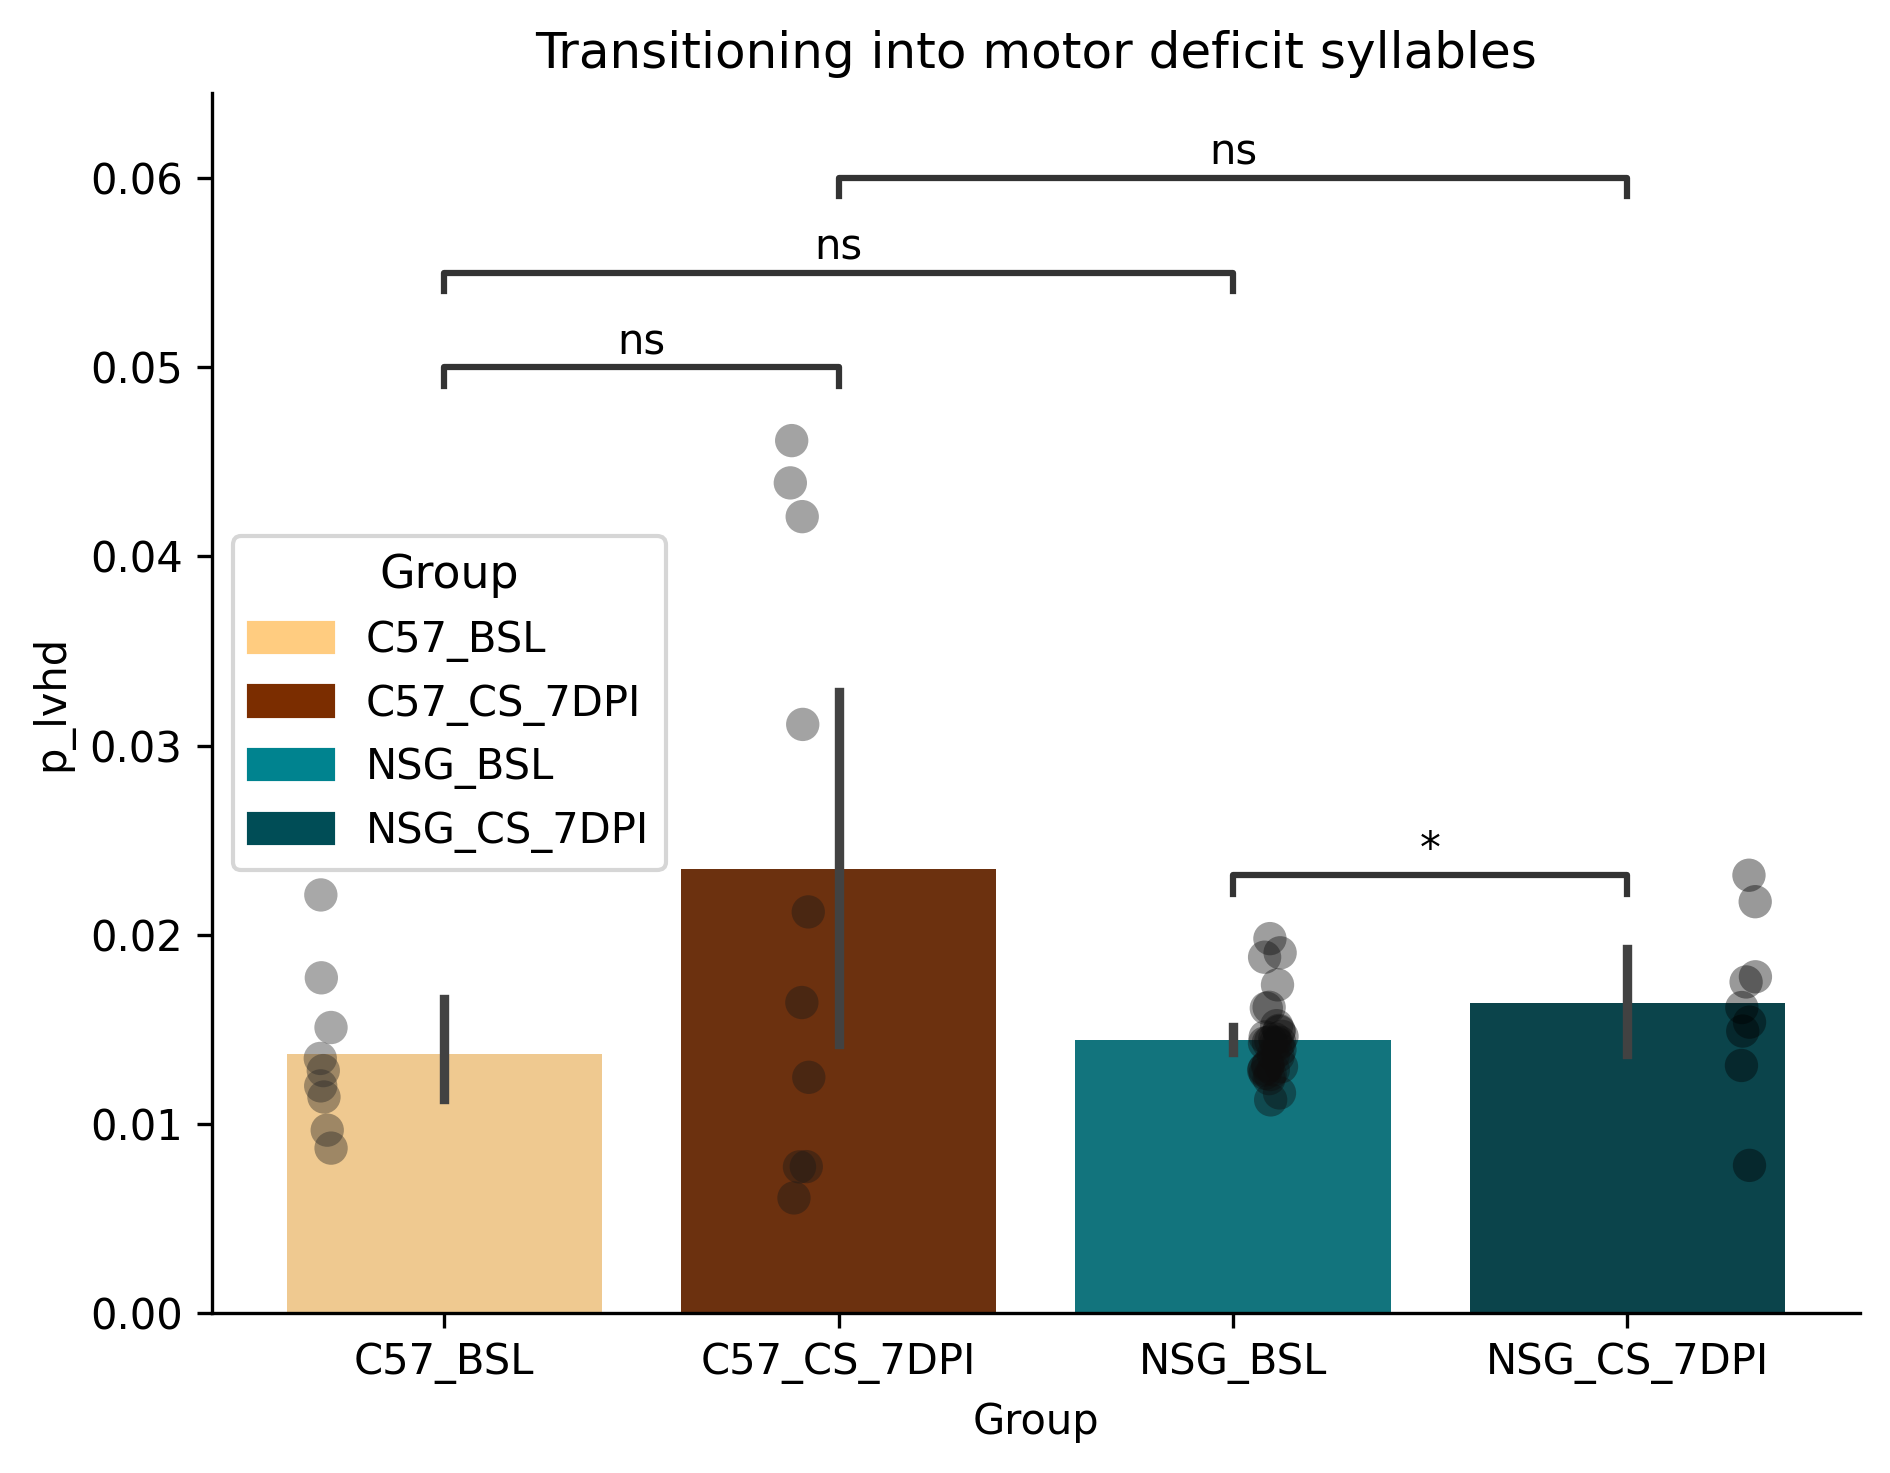

In [56]:
from matplotlib.patches import Patch

order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean_lvhd,
    x='group', y='p_lvhd', hue='group',
    palette=palette,
    order=order,
    hue_order=order,
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean_lvhd,
    x='group', y='p_lvhd', hue='group',
    order=order,
    hue_order=order,
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

pairs = [
    ("C57_BSL", "C57_CS_7DPI"),
    ("NSG_BSL", "NSG_CS_7DPI"),
    ("C57_BSL", "NSG_BSL"),
    ("C57_CS_7DPI", "NSG_CS_7DPI"),
]

annotator = Annotator(
    ax, pairs=pairs,
    data=plot_df_clean_lvhd, x="group", y="p_lvhd", order=order
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=2)
annotator.apply_and_annotate()

ax.set_xlabel('Group')

present_groups = plot_df_clean_lvhd['group'].unique()
handles = [Patch(color=palette[g], label=g) for g in order if g in present_groups]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.title('Transitioning into motor deficit syllables')
plt.savefig(SAVE_PATH / 'Motor_Deficit_Transition_Probability_4groups.pdf')
plt.show()

### 5.2.2 Transition into Cognitive Deficit Syllables (`low_disp_low_vel`)

Low displacement, low velocity syllables — interpreted as low-engagement or repetitive/inactive states associated with cognitive impairment. An increase post-stroke may reflect reduced behavioral flexibility or exploration.

/tmp/ipykernel_20832/1528884779.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.832e-02 U_stat=2.100e+01
NSG_BSL vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:4.630e-03 U_stat=6.600e+01
C57_BSL vs. NSG_BSL: Mann-Whitney-Wilcoxon test two-sided, P_val:7.903e-03 U_stat=2.800e+02
C57_CS_7DPI vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.212e-01 U_stat=7.100e+01


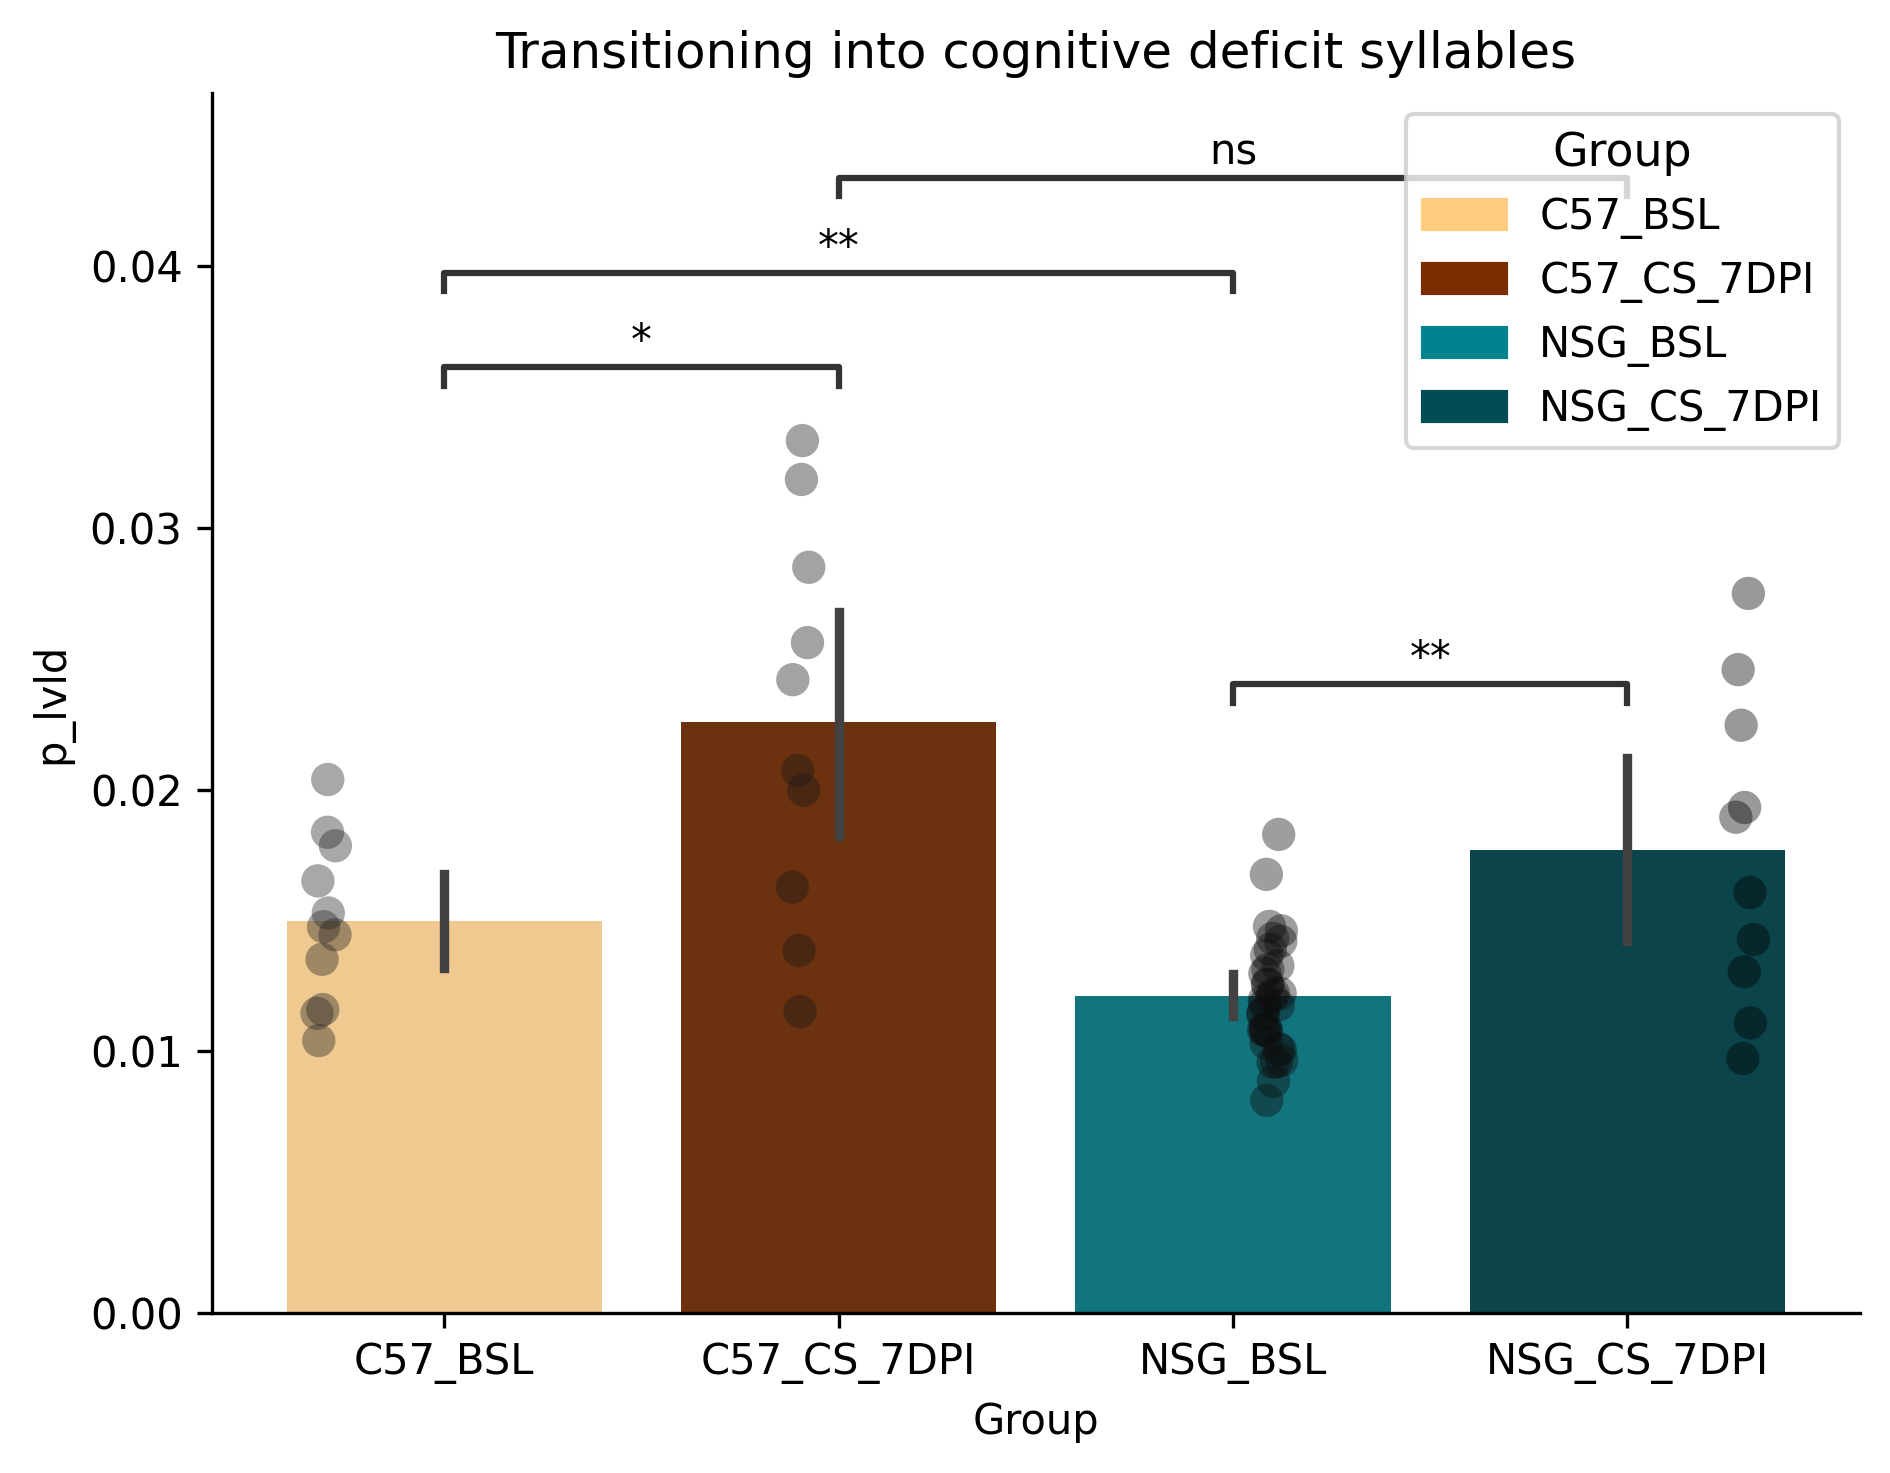

In [57]:
from matplotlib.patches import Patch

order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean_lvld,
    x='group', y='p_lvld', hue='group',
    palette=palette,
    order=order,
    hue_order=order,
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean_lvld,
    x='group', y='p_lvld', hue='group',
    order=order,
    hue_order=order,
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

pairs = [
    ("C57_BSL", "C57_CS_7DPI"),
    ("NSG_BSL", "NSG_CS_7DPI"),
    ("C57_BSL", "NSG_BSL"),
    ("C57_CS_7DPI", "NSG_CS_7DPI"),
]

annotator = Annotator(
    ax, pairs=pairs,
    data=plot_df_clean_lvld, x="group", y="p_lvld", order=order
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside")
annotator.apply_and_annotate()

ax.set_xlabel('Group')

present_groups = plot_df_clean_lvld['group'].unique()
handles = [Patch(color=palette[g], label=g) for g in order if g in present_groups]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.title('Transitioning into cognitive deficit syllables')
plt.savefig(SAVE_PATH / 'Cognitive_Deficit_Transition_Probability_4groups.pdf')
plt.show()

### 5.2.3 Transition into Motor Improvement Syllables (`high_disp_high_vel`)

High displacement, high velocity syllables — energetic, fluid movements associated with intact motor function. A higher transition probability into this cluster post-stroke suggests preserved or recovered motor output.

/tmp/ipykernel_20832/3998580400.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.300e-01 U_stat=7.700e+01
NSG_BSL vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.378e-02 U_stat=7.000e+01
C57_BSL vs. NSG_BSL: Mann-Whitney-Wilcoxon test two-sided, P_val:2.934e-02 U_stat=1.040e+02
C57_CS_7DPI vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:7.963e-03 U_stat=1.200e+01


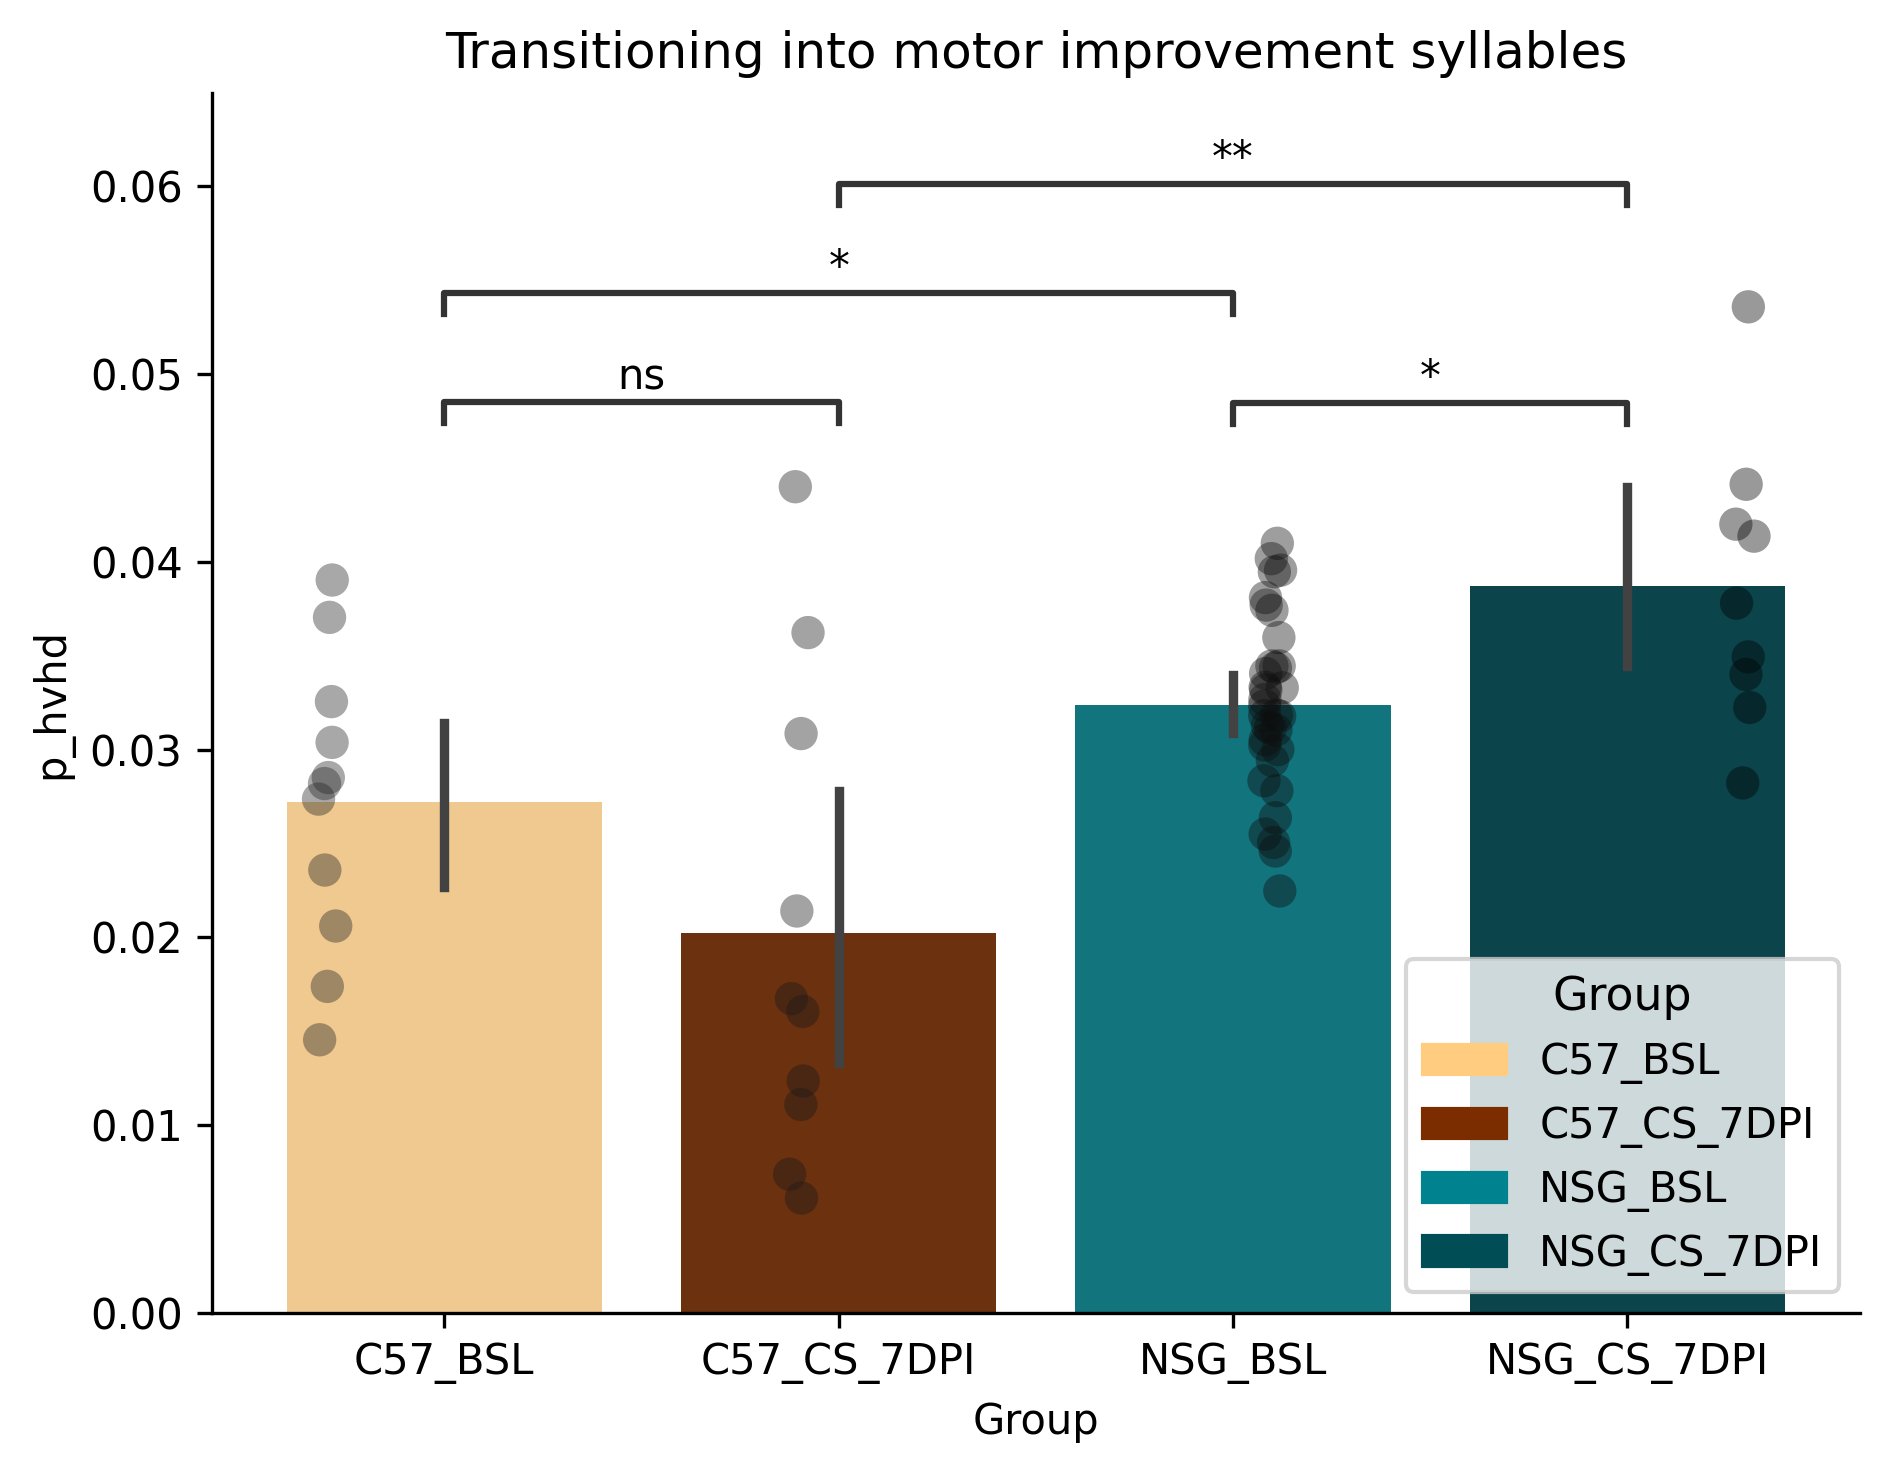

In [59]:
from matplotlib.patches import Patch

order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean_hvhd,
    x='group', y='p_hvhd', hue='group',
    palette=palette,
    order=order,
    hue_order=order,
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean_hvhd,
    x='group', y='p_hvhd', hue='group',
    order=order,
    hue_order=order,
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

pairs = [
    ("C57_BSL", "C57_CS_7DPI"),
    ("NSG_BSL", "NSG_CS_7DPI"),
    ("C57_BSL", "NSG_BSL"),
    ("C57_CS_7DPI", "NSG_CS_7DPI"),
]

annotator = Annotator(
    ax, pairs=pairs,
    data=plot_df_clean_hvhd, x="group", y="p_hvhd", order=order  # fixed: was pointing to plot_df_clean_lvld / p_lvld
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside")
annotator.apply_and_annotate()

ax.set_xlabel('Group')

present_groups = plot_df_clean_hvhd['group'].unique()
handles = [Patch(color=palette[g], label=g) for g in order if g in present_groups]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.title('Transitioning into motor improvement syllables')
plt.savefig(SAVE_PATH / 'Motor_Improvement_Transition_Probability_4groups.pdf')
plt.show()

### 5.2.4 Transition into Cognitive Improvement Syllables (`low_disp_high_vel`)

Low displacement, high velocity syllables — quick, exploratory or attentive movements associated with engaged cognitive state. Higher transition probability into this cluster suggests preserved or recovered cognitive engagement post-stroke.

/tmp/ipykernel_20832/678505201.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:2.730e-01 U_stat=3.500e+01
NSG_BSL vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:2.217e-01 U_stat=2.000e+02
C57_BSL vs. NSG_BSL: Mann-Whitney-Wilcoxon test two-sided, P_val:7.744e-01 U_stat=1.640e+02
C57_CS_7DPI vs. NSG_CS_7DPI: Mann-Whitney-Wilcoxon test two-sided, P_val:2.703e-01 U_stat=5.900e+01


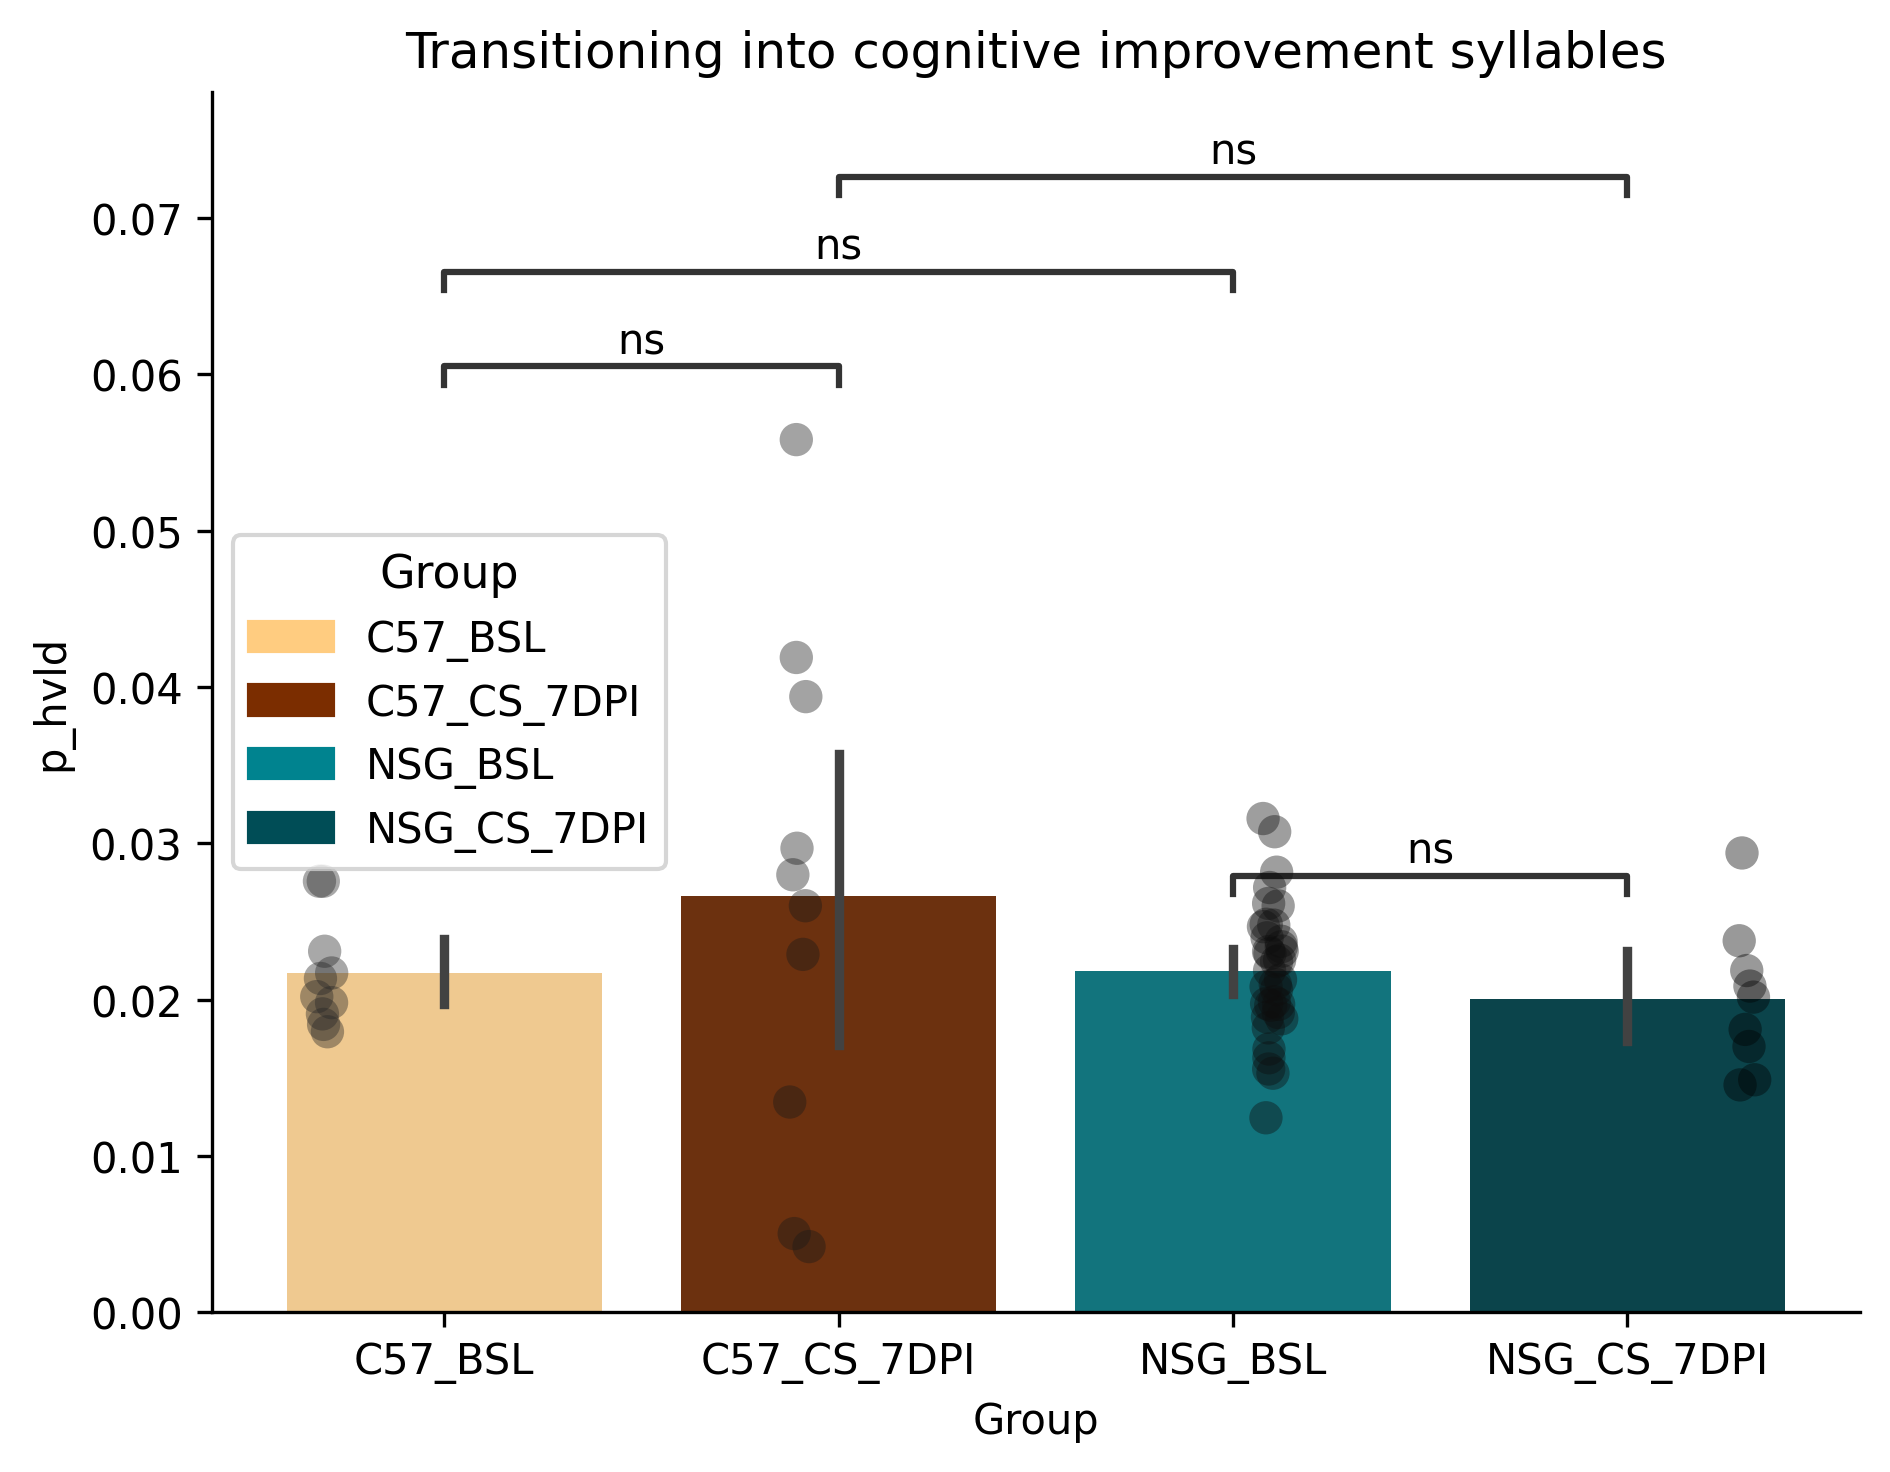

In [60]:
from matplotlib.patches import Patch

order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean_hvld,
    x='group', y='p_hvld', hue='group',
    palette=palette,
    order=order,
    hue_order=order,
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean_hvld,
    x='group', y='p_hvld', hue='group',
    order=order,
    hue_order=order,
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

pairs = [
    ("C57_BSL", "C57_CS_7DPI"),
    ("NSG_BSL", "NSG_CS_7DPI"),
    ("C57_BSL", "NSG_BSL"),
    ("C57_CS_7DPI", "NSG_CS_7DPI"),
]

annotator = Annotator(
    ax, pairs=pairs,
    data=plot_df_clean_hvld, x="group", y="p_hvld", order=order
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside")
annotator.apply_and_annotate()

ax.set_xlabel('Group')

present_groups = plot_df_clean_hvld['group'].unique()
handles = [Patch(color=palette[g], label=g) for g in order if g in present_groups]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.title('Transitioning into cognitive improvement syllables')
plt.savefig(SAVE_PATH / 'Cognitive_Improvement_Transition_Probability_4groups.pdf')
plt.show()